In [1]:
# ==============================================================
# CLASSIFICATION BINAIRE MULTICRITÈRE (PyTorch + M2 Pro GPU)
# ==============================================================
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import re

from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE



from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [2]:
# --------------------------------------------------------------
# 1️. CONFIGURATION GPU MPS
# --------------------------------------------------------------
print("="*70)
print("CONFIGURATION GPU APPLE M2 PRO")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")
print(f"MPS compilé: {torch.backends.mps.is_built()}")

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"✅ Utilisation du device : {device}")
print("="*70, "\n")

CONFIGURATION GPU APPLE M2 PRO
PyTorch version: 2.4.1
MPS disponible: True
MPS compilé: True
✅ Utilisation du device : mps



### Étape A — Ingestion + typage + nettoyage

#### Ingestion 

In [3]:
# 2. CHARGEMENT DU FICHIER ------------------------------------------------
df_fact_acorig = pd.read_csv("data/fisprod_acorriger20260131.csv", sep=',', header=0)
df_fact_valide= pd.read_csv("data/fisprod_valider20260131.csv", sep=',', header=0)
df = pd.concat([df_fact_valide, df_fact_acorig], ignore_index=True, axis=0)
data=df.copy()
colonnes_all=df.columns
#df.head

/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_31445/2774283028.py:3: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fact_valide= pd.read_csv("data/fisprod_valider20260131.csv", sep=',', header=0)


In [4]:
print(" \n colonne retenue\n",df.columns)

 
 colonne retenue
 Index(['id_structure', 'nom_patient', 'village', 'distance_village',
       'age_patient', 'sex', 'parent_name', 'tel', 'visit_date',
       'serie_number', 'registre_number', 'consultation_type',
       'type_prestation', 'num_ordonance', 'quantite_total_prod',
       'quantite_total_act', 'quantite_total_ex', 'cout_total_prod',
       'cout_total_act', 'cout_total_ex', 'type_observation', 'nbre_jours',
       'cout_mise_en_observation', 'cout_evacuation', 'nbre_kilomettre',
       'user_id', 'is_delete', 'id_user_created', 'id_user_updated',
       'id_user_deleted', 'deleted_at', 'created_at', 'updated_at',
       'assurance', 'taux_assurance', 'id', 'structure_assurance',
       'id_prescripteur', 'id_gerant', 'id_village', 'date_entree',
       'date_sortie', 'mode_sortie', 'data_source', 'id_api',
       'mobile_app_version', 'status_verification',
       'observations_verification', 'date_verification',
       'libelle_consultation_type', 'libelle_type_presta

In [5]:
print(df['type_prestation'].value_counts())

type_prestation
20     7127
34     3041
35     1802
6       559
28      491
29      440
11      355
26      306
21      224
7       149
30      144
36       92
16       78
27       77
25       45
12       36
9        16
8        11
31        4
17        2
14        2
18        1
143       1
32        1
158       1
Name: count, dtype: int64


In [6]:
print(df['consultation_type'].value_counts())

consultation_type
4    7352
1    4936
5    1508
2    1128
3      81
Name: count, dtype: int64


In [8]:
print(df['type_observation'].values.tolist())

['ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'hospitalisation', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'observation', 'ambulatoire', 'observation', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'observation', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambulatoire', 'ambu

In [ ]:
print(df['libelle_type_structure'].unique())
print(f"\nNombre de valeurs uniques: {df['libelle_type_structure'].nunique()}")
print(f"\nComptage des valeurs:\n{df['libelle_type_structure'].value_counts()}")

In [ ]:
print(df['id_type_structure'].unique())
print(f"\nNombre de valeurs uniques: {df['id_type_structure'].nunique()}")
print(f"\nComptage des valeurs:\n{df['id_type_structure'].value_counts()}")

In [ ]:
df.info()

#### Nettoyage et typage

In [ ]:
colonnes_a_supprimer = [
       'id_structure',
       'parent_name', 'tel',
       'serie_number', 'num_ordonance', 'nbre_kilomettre',
       'user_id', 'is_delete', 'id_user_created', 'id_user_updated',
       'id_user_deleted', 'deleted_at', 'updated_at',
       'assurance', 'taux_assurance', 'id', 'structure_assurance',
       'id_village', 'data_source', 'id_api',
       'mobile_app_version', 'facture_trouvee',
       'montant_contre_verification', '_conforme',
       'is_contre_verification', 'id_contre_verification', 'observations',
       'numero_assurance', 'id_assurance', 'slug_assurance',
       'autre_type_prestation', 'id_motif', 'autre_motif',
       'qualite_accompagnant','facture_conforme',
       'libelle_consultation_type', 'libelle_type_prestation', 'user_name',
       'libelle_region', 'libelle_province', 'libelle_district',
       'libelle_commune','id_region', 'id_province',
       'id_district', 'id_commune', 'id_fs', 'libelle_mode_sortie',
       'id_niveau_structure',
       'is_public_structure', 'level_structure', 'date_debut', 'date_fin',
       'month_current', 'year_current', 'count_obs', 'count_ev'
]# Supprimer colonnes inutiles

set_all = set(colonnes_all)
set_sup = set(colonnes_a_supprimer)

communes = set_all & set_sup
seulement_all = set_all - set_sup
seulement_sup = set_sup - set_all

print("Colonnes communes :", communes)
print("Colonnes restantes :", seulement_all)
print("Colonnes inexistantes :", seulement_sup)

In [ ]:
# Supprimer colonnes inutiles
df.drop(columns=[c for c in colonnes_a_supprimer if c in df.columns], inplace=True)
print(" colonne de départ\n",data.columns)

In [ ]:
print(" \n colonne retenue\n",df.columns)

In [ ]:
df.head()

In [ ]:
# ---------------------------
# 0) Paramètres
# provenance = village . obligatoire dans le formulaire csps pas pour CMU/CM/CHU/CHR
# ---------------------------
#  observations_verification : contient du texte utile
target_col = "status_verification"

#filled_cols pertinent pour déterminer la complétude des données ' tenir compte de "village",

filled_cols = [
    "nom_patient", "distance_village", "age_patient",
    "registre_number", "id_prescripteur", "id_gerant", "sex", "consultation_type","type_prestation",'id_type_structure', 'visit_date'
]

date_cols = ["date_entree", "date_sortie", "visit_date","created_at"]

num_cols = [
    "distance_village", "age_patient","nbre_jours",
    "quantite_total_prod", "quantite_total_act", "quantite_total_ex",
    "cout_total_prod", "cout_total_act", "cout_total_ex",
    "cout_mise_en_observation", "cout_evacuation"
]

cat_cols = [
    "consultation_type", "type_prestation", "type_observation", "mode_sortie", 'libelle_fs', 'libelle_type_structure'
]

In [20]:
def to_float(x):
    """Convertit en float (gère '1 234,56', '1,234.56', etc.)."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)

    s = str(x).strip().lower()
    if s in {"", "none", "nan", "null"}:
        return np.nan

    s = re.sub(r"[^0-9\-,.]", "", s)

    # 1234,56 -> 1234.56
    if s.count(",") == 1 and s.count(".") == 0:
        s = s.replace(",", ".")

    # 1,234.56 -> 1234.56
    if s.count(",") > 0 and s.count(".") == 1:
        s = s.replace(",", "")

    try:
        return float(s)
    except:
        return np.nan

def encode_sex(x):
    """male=1 / female=2"""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"m", "male", "masculin", "homme", "1"}:
        return 1
    if s in {"f", "female", "feminin", "féminin", "femme", "2"}:
        return 2
    return np.nan

In [21]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1) flags "is_filled" (1 si rempli sinon 0) : complétude des données
    filled_cols = ["nom_patient", "distance_village", "age_patient",
                   "registre_number", "id_prescripteur", "id_gerant"]
   
            ,
            "nom_patient',
            "prestation',
            "provenance',
            "sexe',
            "type_prestation',
            "nom_gerant',
            "visit_date',
    for c in filled_cols:
        df[f"{c}_is_filled"] = df[c].notna().astype(int) if c in df.columns else 0

    # 2) sex -> sex_code
    df["sex_code"] = df["sex"].apply(encode_sex) if "sex" in df.columns else np.nan

    # 3) dates -> datetime
    date_cols = ["date_entree", "date_sortie", "visit_date"]
    for c in date_cols:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True) if c in df.columns else pd.NaT

    # features dates utiles
    df["delta_days"] = (df["date_sortie"] - df["date_entree"]).dt.days
    df["visit_year"] = df["visit_date"].dt.year
    df["visit_month"] = df["visit_date"].dt.month
    df["visit_dow"] = df["visit_date"].dt.dayofweek

    df["has_date_issue"] = (
        df["date_entree"].isna()
        | df["visit_date"].isna()
        | (df["date_sortie"].notna() & df["date_entree"].notna() & (df["date_sortie"] < df["date_entree"]))
    ).astype(int)

    # 4) colonnes numériques (quantités / montants)
    num_cols = [
        "distance_village", "age_patient",
        "quantite_total_prod", "quantite_total_act", "quantite_total_ex",
        "cout_total_prod", "cout_total_act", "cout_total_ex",
        "cout_mise_en_observation", "cout_evacuation"
    ]
    for c in num_cols:
        df[c] = df[c].apply(to_float) if c in df.columns else np.nan

    # (option) enlever valeurs négatives
    for c in ["quantite_total_prod", "quantite_total_act", "quantite_total_ex", "nbre_jours", "nbre_kilomettre",
              "cout_total_prod", "cout_total_act", "cout_total_ex", "cout_mise_en_observation", "cout_evacuation"]:
        if c in df.columns:
            df.loc[df[c] < 0, c] = np.nan

    # 5) agrégats
    df["cout_total_global"] = (
        df["cout_total_prod"].fillna(0)
        + df["cout_total_act"].fillna(0)
        + df["cout_total_ex"].fillna(0)
        + df["cout_mise_en_observation"].fillna(0)
        + df["cout_evacuation"].fillna(0)
    )

    denom = (
        df["quantite_total_prod"].fillna(0)
        + df["quantite_total_act"].fillna(0)
        + df["quantite_total_ex"].fillna(0)
    )
    df["unit_cost_global"] = np.where(denom > 0, df["cout_total_global"] / denom, np.nan)

    return df


In [24]:
df=build_features(df)
df.columns

Index(['nom_patient', 'distance_village', 'age_patient', 'sex', 'visit_date',
       'registre_number', 'consultation_type', 'type_prestation',
       'quantite_total_prod', 'quantite_total_act', 'quantite_total_ex',
       'cout_total_prod', 'cout_total_act', 'cout_total_ex',
       'type_observation', 'cout_mise_en_observation', 'cout_evacuation',
       'id_prescripteur', 'id_gerant', 'date_entree', 'date_sortie',
       'mode_sortie', 'status_verification', 'observations_verification',
       'date_verification', 'nom_patient_is_filled',
       'distance_village_is_filled', 'age_patient_is_filled',
       'registre_number_is_filled', 'id_prescripteur_is_filled',
       'id_gerant_is_filled', 'sex_code', 'delta_days', 'visit_year',
       'visit_month', 'visit_dow', 'has_date_issue', 'nbre_jours',
       'nbre_kilomettre', 'cout_total_global', 'unit_cost_global'],
      dtype='object')

Entraîner le modèle

In [23]:
def train_pipeline(df: pd.DataFrame, save_path="pipeline_status.joblib"):
    # 1) features
    df_feat = build_features(df)

    # 2) X / y
    y = df_feat["status_verification"].astype(str)

    cat_cols = ["consultation_type", "type_prestation", "type_observation", "mode_sortie"]
    # on garde les colonnes qui existent
    cat_cols = [c for c in cat_cols if c in df_feat.columns]

    # toutes les features qu'on veut utiliser
    feature_cols = [c for c in df_feat.columns if c != "status_verification"]

    X = df_feat[feature_cols].copy()

    # 3) split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4) prétraitement
    numeric_features = [c for c in X.columns if c not in cat_cols]
    categorical_features = cat_cols

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]), numeric_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_features),
        ]
    )

    # 5) modèle (LightGBM si dispo sinon fallback sklearn)
    try:
        import lightgbm as lgb
        clf = lgb.LGBMClassifier(
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42
        )
    except Exception:
        from sklearn.ensemble import HistGradientBoostingClassifier
        clf = HistGradientBoostingClassifier(random_state=42)

    # 6) class weights (si classes déséquilibrées)
    classes = np.unique(y_train)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight = {c: w for c, w in zip(classes, cw)}
    try:
        clf.set_params(class_weight=class_weight)
    except Exception:
        pass

    # 7) pipeline final : preprocess -> model
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", clf)
    ])

    model.fit(X_train, y_train)

    # 8) évaluation
    y_pred = model.predict(X_test)
    print("\n=== Classification report ===")
    print(classification_report(y_test, y_pred, digits=4))
    print("\n=== Confusion matrix ===")
    print(confusion_matrix(y_test, y_pred, labels=classes))

    # 9) save
    joblib.dump({"model": model, "feature_builder": build_features}, save_path)
    print(f"\n✅ Sauvegardé: {save_path}")

    return model


Prédire une facture (1 ligne)

In [ ]:
def predict_one(row: dict, model_path="pipeline_status.joblib"):
    saved = joblib.load(model_path)
    model = saved["model"]
    fb = saved["feature_builder"]

    df = pd.DataFrame([row])
    df_feat = fb(df)

    X = df_feat.drop(columns=["status_verification"], errors="ignore")
    pred = model.predict(X)[0]

    proba = None
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)[0]
        proba = {model.classes_[i]: float(p[i]) for i in range(len(model.classes_))}

    return {"status_pred": pred, "proba": proba}


In [ ]:

# Nettoyage
X[vars_num] = X[vars_num].fillna(0)
X[vars_cat] = X[vars_cat].fillna("inconnu")

# Encodage
for col in vars_cat:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# --------------------------------------------------------------
# 3. ÉQUILIBRAGE DES CLASSES
# --------------------------------------------------------------
print("Avant SMOTE :", np.bincount(y))
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print("Après SMOTE :", np.bincount(y_res))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)

In [ ]:
# --------------------------------------------------------------
# 4️⃣ CONVERSION EN TENSEURS PyTorch
# --------------------------------------------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, "values") else y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values if hasattr(y_test, "values") else y_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

In [ ]:
# --------------------------------------------------------------
# 5. DÉFINITION DU MODÈLE (MLP)
# --------------------------------------------------------------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:

# --------------------------------------------------------------
# 6. ENTRAÎNEMENT
# --------------------------------------------------------------
EPOCHS = 30
best_f1, patience, wait = 0, 5, 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).view(-1, 1)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        preds, trues = [], []
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds.extend(outputs.cpu().numpy())
            trues.extend(yb.numpy())

        preds_bin = (np.array(preds).flatten() > 0.5).astype(int)
        f1 = f1_score(trues, preds_bin)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f} - F1: {f1:.4f}")

    # Early stopping
    if f1 > best_f1:
        best_f1, wait = f1, 0
        torch.save(model.state_dict(), "best_model_mps.pt")
    else:
        wait += 1
        if wait >= patience:
            print("⏹️  Early stopping.")
            break

Avant SMOTE : [10000 10000]
Après SMOTE : [10000 10000]
Epoch 1/30 - Loss: 0.5058 - F1: 0.8823
Epoch 2/30 - Loss: 0.3019 - F1: 0.9025
Epoch 3/30 - Loss: 0.2539 - F1: 0.9115
Epoch 4/30 - Loss: 0.2531 - F1: 0.9087
Epoch 5/30 - Loss: 0.2351 - F1: 0.9120
Epoch 6/30 - Loss: 0.2343 - F1: 0.9116
Epoch 7/30 - Loss: 0.2429 - F1: 0.9146
Epoch 8/30 - Loss: 0.2511 - F1: 0.9145
Epoch 9/30 - Loss: 0.2349 - F1: 0.9175
Epoch 10/30 - Loss: 0.2254 - F1: 0.9183
Epoch 11/30 - Loss: 0.2364 - F1: 0.9152
Epoch 12/30 - Loss: 0.2345 - F1: 0.9156
Epoch 13/30 - Loss: 0.2327 - F1: 0.9152
Epoch 14/30 - Loss: 0.2313 - F1: 0.9172
Epoch 15/30 - Loss: 0.2172 - F1: 0.9195
Epoch 16/30 - Loss: 0.2214 - F1: 0.9208
Epoch 17/30 - Loss: 0.2310 - F1: 0.9220
Epoch 18/30 - Loss: 0.2180 - F1: 0.9222
Epoch 19/30 - Loss: 0.2112 - F1: 0.9226
Epoch 20/30 - Loss: 0.2229 - F1: 0.9240
Epoch 21/30 - Loss: 0.2181 - F1: 0.9198
Epoch 22/30 - Loss: 0.2174 - F1: 0.9190
Epoch 23/30 - Loss: 0.2006 - F1: 0.9302
Epoch 24/30 - Loss: 0.1995 - F1: 

/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_19754/3261235834.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mode

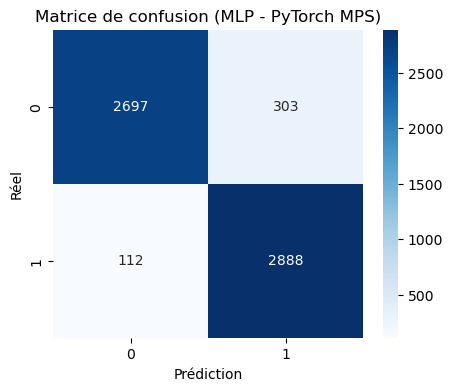

In [4]:

# --------------------------------------------------------------
# 7️⃣ ÉVALUATION FINALE
# --------------------------------------------------------------
model.load_state_dict(torch.load("best_model_mps.pt"))
model.eval()
with torch.no_grad():
    y_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        y_pred.extend(outputs.cpu().numpy())
y_pred_bin = (np.array(y_pred).flatten() > 0.5).astype(int)

print("\n===== RAPPORT DE CLASSIFICATION =====")
print(classification_report(y_test, y_pred_bin))

cm = confusion_matrix(y_test, y_pred_bin)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion (MLP - PyTorch MPS)")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

# --------------------------------------------------------------
# 8️⃣ SAUVEGARDE DU RAPPORT
# --------------------------------------------------------------
with open("rapport_classification_torch.txt", "w", encoding="utf-8") as f:
    f.write("===== RAPPORT DE CLASSIFICATION (PyTorch M2 Pro) =====\n\n")
    f.write(classification_report(y_test, y_pred_bin))
    f.write(f"\nF1-score final : {best_f1:.4f}\n")
